# Biology-aware extension to the response classifier

This notebook extends `4_simplify_pipe.ipynb` by injecting **melanoma biology** into the feature space:

1. **Hallmark + KEGG pathway scores** via ssGSEA (collapses ~thousands of genes into ~80 interpretable scores)
2. **Custom melanoma signatures**: IPRES (innate anti-PD-1 resistance), IFN-γ GEP (Ayers), MAPK output, MITF program, AXL/dedifferentiation
3. **Canonical gene whitelist** kept at gene-level: BRAF, NRAS, MITF, AXL, PTEN, CD274, CD8A, IFNG, B2M, HLA-A, etc.
4. Pipeline mirrors the original (ColumnTransformer → scaler → LogisticRegression, Optuna-tuned, 5-fold CV)

**Why this should help**: 500 genes selected by univariate F-test is noisy on small cohorts and ignores known biology. Pathway scores are denoised summaries of coordinated gene programs, and known melanoma signatures encode prior knowledge that's directly relevant to ICI / MAPKi response.

**Note on leakage**: ssGSEA scores each sample independently (no cross-sample fitting), so it's safe to precompute scores once on the full `gex_mat` and use them across CV folds.


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import optuna

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.model_selection import StratifiedKFold, cross_validate, cross_val_predict, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import VarianceThreshold, SelectKBest, f_classif

import gseapy as gp
import shap
shap.initjs()


## 1. Load data (same as original pipeline)

In [9]:
# Same loading as original notebook
gex_mat = pd.read_csv('../dataset/created/gex_mat_corrected.csv').set_index('sample_id')
# gex_mat: rows=genes (HGNC), cols=samples  (the CSV was written genes×samples from R)
gex_mat.index.name = 'gene'
print('gex_mat (genes x samples):', gex_mat.shape)

clinical_gex = pd.read_csv('../dataset/created/clinical_gex.csv', low_memory=False)
print('clinical_gex:', clinical_gex.shape)


gex_mat (genes x samples): (17379, 136)
clinical_gex: (136, 51487)


In [10]:
# Same column groups as original
clinical_ordinal_col       = ['M_stage']
clinical_categorical_cols  = ['sex', 'AJCC_stage', 'LDH', 'immunotherapy_treatment', 'pre_MAPKi_treatment']
clinical_numeric_col       = ['age']
clinical_drug_braf_cols    = ['cobimetinib', 'trametinib', 'dabrafenib', 'vemurafenib',
                              'C195W', 'K601I', 'MND', 'V600E', 'V600K', 'V600R']
clinical_remaining_cols    = ['patientID', 'sample_id', 'pfs_label', 'source']

clinical_drug_braf_cols = [c for c in clinical_drug_braf_cols if c in clinical_gex.columns]

CLINICAL_COLS  = (clinical_ordinal_col + clinical_categorical_cols + clinical_numeric_col
                  + clinical_drug_braf_cols + clinical_remaining_cols)
GEX_COLS_ORI   = [c for c in clinical_gex.columns if c not in CLINICAL_COLS]
print(f'clinical={len(CLINICAL_COLS)}  gex={len(GEX_COLS_ORI)}')


clinical=21  gex=51466


## 2. Define melanoma-relevant gene sets

We use three sources:

- **Hallmark (MSigDB H)**: 50 well-curated cancer-relevant pathways (MAPK, PI3K-AKT, IFN-α/γ response, EMT, hypoxia, etc.). Pulled from Enrichr via gseapy.
- **KEGG 2021 Human**: pathway gene sets including `Melanoma`, `MAPK signaling`, `PD-L1 expression and PD-1 checkpoint`, etc.
- **Custom melanoma signatures**: hand-curated from key papers (IPRES, IFN-γ GEP, MITF/AXL programs).

If you're offline or want full reproducibility, replace `gp.get_library('...')` with a local `.gmt` file.


In [11]:
# Pull Hallmark + KEGG from Enrichr (cached locally by gseapy after first call)
hallmark = gp.get_library(name='MSigDB_Hallmark_2020', organism='Human')
kegg     = gp.get_library(name='KEGG_2021_Human',       organism='Human')

print(f'Hallmark sets: {len(hallmark)}')
print(f'KEGG sets:     {len(kegg)}')

# Keep only KEGG sets that are plausibly melanoma/immune/signaling-relevant.
# (Optional: drop this filter to use all KEGG sets.)
kegg_keywords = [
    'melanoma', 'mapk', 'pi3k', 'akt', 'mtor', 'wnt', 'notch', 'tgf',
    'cell cycle', 'p53', 'apoptosis', 'dna repair', 'mismatch',
    'pd-l1', 'pd-1', 'antigen', 'natural killer', 't cell', 'b cell',
    'cytokine', 'chemokine', 'jak-stat', 'nf-kappa', 'toll-like',
    'oxidative phosphorylation', 'glycolysis', 'fatty acid', 'hypoxia',
    'ecm-receptor', 'focal adhesion',
]
kegg_filtered = {
    k: v for k, v in kegg.items()
    if any(kw in k.lower() for kw in kegg_keywords)
}
print(f'KEGG filtered: {len(kegg_filtered)}')


Hallmark sets: 50
KEGG sets:     320
KEGG filtered: 31


In [12]:
# Custom melanoma signatures from the literature.
# Trimmed gene lists -- you can extend these from the original supplementary tables.
melanoma_sigs = {

    # Ayers et al. 2017 -- Tumor Inflammation Signature / IFN-gamma GEP (18 genes, predicts ICI response)
    'IFNg_GEP_Ayers': [
        'CD8A', 'CCL5', 'CD27', 'CXCL9', 'CXCR6', 'IDO1', 'STAT1',
        'CD274', 'CD276', 'PDCD1LG2', 'LAG3', 'NKG7', 'PSMB10',
        'CMKLR1', 'TIGIT', 'HLA-DQA1', 'HLA-DRB1', 'HLA-E',
    ],

    # Hugo et al. 2016 -- IPRES (Innate anti-PD-1 Resistance) -- subset of representative genes
    'IPRES_Hugo': [
        'AXL', 'WNT5A', 'ROR2', 'TWIST2', 'TAGLN', 'LOXL2', 'FAP',
        'COL5A1', 'COL5A2', 'COL6A3', 'FN1', 'VIM', 'ZEB1', 'SNAI2',
        'PDGFRA', 'PDGFRB', 'TGFB1', 'TGFB2', 'TGFBR2',
    ],

    # MAPK pathway output / BRAFi-relevant signaling
    'MAPK_output': [
        'BRAF', 'NRAS', 'KRAS', 'HRAS', 'MAP2K1', 'MAP2K2', 'MAPK1', 'MAPK3',
        'DUSP4', 'DUSP6', 'SPRY2', 'SPRY4', 'ETV4', 'ETV5', 'PHLDA1', 'CCND1',
        'FOS', 'EGR1',
    ],

    # MITF melanocytic / proliferative program (Hoek/Tirosh)
    'MITF_program': [
        'MITF', 'TYR', 'TYRP1', 'DCT', 'MLANA', 'PMEL', 'SOX10', 'PAX3',
        'GPNMB', 'MLPH', 'OCA2', 'RAB27A', 'SLC45A2', 'TRPM1',
    ],

    # AXL / invasive / dedifferentiated program (anti-correlated with MITF)
    'AXL_invasive': [
        'AXL', 'WNT5A', 'NRP1', 'PDGFRB', 'TGFBI', 'CDH13', 'ANXA1',
        'NGFR', 'EGFR', 'FN1', 'INHBA', 'JUN', 'FOSL1',
    ],

    # Antigen presentation -- HLA class I machinery (loss => ICI resistance)
    'Antigen_presentation_MHCI': [
        'B2M', 'HLA-A', 'HLA-B', 'HLA-C', 'HLA-E', 'HLA-F',
        'TAP1', 'TAP2', 'TAPBP', 'PSMB8', 'PSMB9', 'NLRC5', 'CALR', 'CANX',
    ],

    # Exhausted / dysfunctional T cell
    'T_cell_exhaustion': [
        'PDCD1', 'CTLA4', 'LAG3', 'TIGIT', 'HAVCR2', 'TOX', 'EOMES',
        'BATF', 'NR4A1', 'NR4A2', 'NR4A3', 'ENTPD1',
    ],

    # Cytotoxic T / effector
    'Cytotoxic_effector': [
        'CD8A', 'CD8B', 'GZMA', 'GZMB', 'GZMH', 'GZMK', 'PRF1',
        'IFNG', 'TNF', 'NKG7', 'GNLY', 'KLRG1',
    ],
}

print(f'Custom melanoma signatures: {len(melanoma_sigs)}')
for k, v in melanoma_sigs.items():
    print(f'  {k:30s} {len(v):3d} genes')


Custom melanoma signatures: 8
  IFNg_GEP_Ayers                  18 genes
  IPRES_Hugo                      19 genes
  MAPK_output                     18 genes
  MITF_program                    14 genes
  AXL_invasive                    13 genes
  Antigen_presentation_MHCI       14 genes
  T_cell_exhaustion               12 genes
  Cytotoxic_effector              12 genes


In [13]:
# Combine all gene-set libraries into one dict for ssGSEA
all_gene_sets = {}
all_gene_sets.update({f'H_{k}':    v for k, v in hallmark.items()})
all_gene_sets.update({f'KEGG_{k}': v for k, v in kegg_filtered.items()})
all_gene_sets.update({f'MEL_{k}':  v for k, v in melanoma_sigs.items()})
print(f'Total gene sets to score: {len(all_gene_sets)}')

# Sanity check: how much overlap with our gene universe?
gex_genes = set(gex_mat.index.astype(str))
coverage = pd.Series({
    name: len(set(genes) & gex_genes) / max(1, len(genes))
    for name, genes in all_gene_sets.items()
})
print(f'Mean coverage of gene sets in gex_mat: {coverage.mean():.2%}')
print(f'Sets with <30% coverage (will likely be dropped by min_size): {(coverage < 0.3).sum()}')


Total gene sets to score: 89
Mean coverage of gene sets in gex_mat: 95.47%
Sets with <30% coverage (will likely be dropped by min_size): 0


## 3. Run ssGSEA -> pathway scores per sample

This produces a `samples x pathways` matrix. Sets that don't have at least `min_size=10` genes overlapping with `gex_mat` are dropped automatically.


In [14]:
# gseapy.ssgsea expects: rows = genes, cols = samples (which is what gex_mat already is)
ssgsea_res = gp.ssgsea(
    data=gex_mat,
    gene_sets=all_gene_sets,
    outdir=None,
    sample_norm_method='rank',
    min_size=10,
    max_size=500,
    permutation_num=0,   # 0 => deterministic ssGSEA scores, no p-values
    no_plot=True,
    threads=4,
    seed=42,
    verbose=False,
)

# res2d is long-format: columns include 'Name' (sample), 'Term' (pathway), 'NES'
nes_long = ssgsea_res.res2d
print(nes_long.head())
print('long shape:', nes_long.shape)


              Name                           Term           ES       NES
0        05320452B  MEL_Antigen_presentation_MHCI  8025.734383  0.505692
1  28702_075A PreB  MEL_Antigen_presentation_MHCI  8020.845454  0.505384
2  28702_010D PreB  MEL_Antigen_presentation_MHCI  8001.687688  0.504177
3  45534_085E PreB  MEL_Antigen_presentation_MHCI   7946.04329  0.500671
4  45534_072K PreB  MEL_Antigen_presentation_MHCI  7932.009819  0.499787
long shape: (12104, 4)


In [15]:
# Pivot to wide: samples x pathways using NES (normalized enrichment score)
pathway_scores = (
    nes_long
    .pivot(index='Name', columns='Term', values='NES')
    .astype(float)
)
pathway_scores.index.name = 'sample_id'
pathway_scores.columns = [f'pw__{c}' for c in pathway_scores.columns]  # prefix for traceability
print('pathway_scores (samples x pathways):', pathway_scores.shape)
pathway_scores.head()


pathway_scores (samples x pathways): (136, 89)


,pw__H_Adipogenesis,pw__H_Allograft Rejection,pw__H_Androgen Response,pw__H_Angiogenesis,pw__H_Apical Junction,pw__H_Apical Surface,pw__H_Apoptosis,pw__H_Bile Acid Metabolism,pw__H_Cholesterol Homeostasis,pw__H_Coagulation,...,pw__KEGG_mTOR signaling pathway,pw__KEGG_p53 signaling pathway,pw__MEL_AXL_invasive,pw__MEL_Antigen_presentation_MHCI,pw__MEL_Cytotoxic_effector,pw__MEL_IFNg_GEP_Ayers,pw__MEL_IPRES_Hugo,pw__MEL_MAPK_output,pw__MEL_MITF_program,pw__MEL_T_cell_exhaustion
sample_id,,,,,,,,,,,,,,,,,,,,,
03660445B,0.301570,0.195157,0.264431,0.235144,0.164082,0.108395,0.296995,0.092402,0.283381,0.168273,...,0.162320,0.217934,0.178388,0.461595,0.119380,0.240371,0.233918,0.386204,0.279258,0.088677
03660447B,0.303624,0.099511,0.246930,0.271130,0.181012,0.115080,0.277748,0.085841,0.279365,0.170205,...,0.161733,0.222356,0.280749,0.400346,-0.020275,0.130486,0.314684,0.387414,0.170901,0.019196
03660502B,0.296934,0.167872,0.251570,0.222640,0.171877,0.083922,0.293831,0.100929,0.279573,0.170350,...,0.163773,0.201115,0.170484,0.475458,0.067510,0.229693,0.185694,0.362381,0.353790,0.052450
03660555B,0.305762,0.165002,0.260688,0.269487,0.173310,0.110779,0.294566,0.086554,0.268470,0.184663,...,0.166237,0.206865,0.169718,0.425676,0.113184,0.225054,0.196600,0.385780,0.320768,0.063743
03660598B,0.313269,0.114526,0.229451,0.191752,0.152304,0.088818,0.274184,0.092551,0.263281,0.151509,...,0.169873,0.188172,0.107802,0.453210,-0.001074,0.183121,0.170354,0.367762,0.381577,0.011143


## 4. Build the feature frame

We merge:

- Clinical features (same as before)
- Pathway scores (new)
- A canonical melanoma gene whitelist (kept at gene-level for interpretability)

We **drop** the 500-gene `SelectKBest` block by default. Toggle `KEEP_RAW_GEX=True` to keep it as a third feature block (you may want to compare both).


In [16]:
# Canonical melanoma genes to keep at gene-level (always included if present)
CANONICAL_GENES = [
    # MAPK / drivers
    'BRAF', 'NRAS', 'KIT', 'MAP2K1', 'NF1',
    # Tumor suppressors
    'PTEN', 'CDKN2A', 'TP53',
    # Phenotype switching
    'MITF', 'AXL', 'SOX10', 'NGFR',
    # Immune / ICI biomarkers
    'CD274', 'PDCD1', 'CTLA4', 'LAG3', 'CD8A', 'IFNG', 'GZMB', 'PRF1',
    # Antigen presentation
    'B2M', 'HLA-A', 'HLA-B', 'HLA-C', 'TAP1', 'TAP2',
]
canonical_present = [g for g in CANONICAL_GENES if g in gex_mat.index]
missing = [g for g in CANONICAL_GENES if g not in gex_mat.index]
print(f'Canonical genes kept: {len(canonical_present)}/{len(CANONICAL_GENES)}')
if missing:
    print(f'Missing: {missing}')


Canonical genes kept: 25/26
Missing: ['HLA-B']


In [17]:
KEEP_RAW_GEX = False  # if True, also keep the 500-gene SelectKBest block

# Start from clinical part of clinical_gex
df = clinical_gex[CLINICAL_COLS].copy()

# Merge pathway scores on sample_id
df = df.merge(pathway_scores, left_on='sample_id', right_index=True, how='inner')

# Merge canonical gene expression on sample_id
canonical_expr = gex_mat.loc[canonical_present].T.copy()  # samples x canonical genes
canonical_expr.columns = [f'gene__{c}' for c in canonical_expr.columns]
canonical_expr.index.name = 'sample_id'
df = df.merge(canonical_expr, left_on='sample_id', right_index=True, how='inner')

# Optionally also merge full gex matrix for the SelectKBest block
if KEEP_RAW_GEX:
    full_gex = gex_mat.T.copy()
    full_gex.index.name = 'sample_id'
    full_gex.columns = [f'rawgex__{c}' for c in full_gex.columns]
    df = df.merge(full_gex, left_on='sample_id', right_index=True, how='inner')

print('Merged feature frame:', df.shape)

PATHWAY_COLS   = [c for c in df.columns if c.startswith('pw__')]
CANONICAL_COLS = [c for c in df.columns if c.startswith('gene__')]
RAWGEX_COLS    = [c for c in df.columns if c.startswith('rawgex__')]
print(f'  pathway features:   {len(PATHWAY_COLS)}')
print(f'  canonical genes:    {len(CANONICAL_COLS)}')
print(f'  raw gex (optional): {len(RAWGEX_COLS)}')


Merged feature frame: (136, 135)
  pathway features:   89
  canonical genes:    25
  raw gex (optional): 0


In [18]:
# Strip whitespace, split x / y -- same convention as original notebook
df.columns = df.columns.str.strip()

y = df['pfs_label']
x = df.drop(clinical_remaining_cols, axis=1)

print(f'x: {x.shape}')
print(f'\nTarget distribution:\n{y.value_counts().sort_index()}')


x: (136, 131)

Target distribution:
pfs_label
0    70
1    66
Name: count, dtype: int64


## 5. Preprocessing pipeline

Same structure as the original `ColumnTransformer`, with two new blocks:

- `pathway`: median-impute + StandardScaler (already roughly standardized but be safe)
- `canonical_gex`: median-impute + StandardScaler

The original `gex` block (variance + SelectKBest) is only included if `KEEP_RAW_GEX=True`.


In [19]:
transformers = [
    ('m_stage', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OrdinalEncoder(
            categories=[['M1A', 'M1B', 'M1C']],
            handle_unknown='use_encoded_value',
            unknown_value=np.nan,
        )),
    ]), clinical_ordinal_col),

    ('categorical', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('ohe', OneHotEncoder(sparse_output=False, handle_unknown='ignore')),
    ]), clinical_categorical_cols),

    ('age',       SimpleImputer(strategy='median'),  clinical_numeric_col),
    ('drug_braf', 'passthrough',                      clinical_drug_braf_cols),

    # NEW: pathway scores
    ('pathway', Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
    ]), PATHWAY_COLS),

    # NEW: canonical melanoma genes at gene-level
    ('canonical_gex', Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
    ]), CANONICAL_COLS),
]

if KEEP_RAW_GEX:
    transformers.append((
        'rawgex', Pipeline([
            ('variance', VarianceThreshold(threshold=0.1)),
            ('kbest',    SelectKBest(f_classif, k=500)),
        ]), RAWGEX_COLS,
    ))

preprocess_features = ColumnTransformer(transformers=transformers, remainder='drop')


In [20]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

lr_clf = LogisticRegression(
    solver='saga',
    class_weight='balanced',
    max_iter=5000,
    random_state=42,
)

full_pipe = Pipeline([
    ('preprocess', preprocess_features),
    ('scaler',     StandardScaler()),
    ('clf',        lr_clf),
])


## 6. Hyperparameter tuning (same as original)

In [21]:
def objective(trial):
    params = {
        'clf__C':        trial.suggest_float('clf__C', 1e-5, 10.0, log=True),
        'clf__l1_ratio': trial.suggest_categorical('clf__l1_ratio', [0.0, 1.0]),
    }
    full_pipe.set_params(**params)
    scores = cross_val_score(full_pipe, x, y, cv=skf, scoring='f1', n_jobs=-1)
    return scores.mean()

study = optuna.create_study(direction='maximize',
                            sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(objective, n_trials=50, show_progress_bar=True)

print(study.best_params)
print(f'Best CV F1: {study.best_value:.3f}')


[I 2026-05-05 14:45:16,823] A new study created in memory with name: no-name-ce29b7ed-227f-4d0d-8829-83e81c85ca33
Best trial: 0. Best value: 0.501967:   2%|▏         | 1/50 [00:01<01:26,  1.77s/it]

[I 2026-05-05 14:45:18,610] Trial 0 finished with value: 0.50196743996744 and parameters: {'clf__C': 0.0017670169402947942, 'clf__l1_ratio': 0.0}. Best is trial 0 with value: 0.50196743996744.


Best trial: 3. Best value: 0.652333:   8%|▊         | 4/50 [00:03<00:26,  1.76it/s]

[I 2026-05-05 14:45:19,769] Trial 1 finished with value: 0.6273186813186813 and parameters: {'clf__C': 0.03907967156822877, 'clf__l1_ratio': 0.0}. Best is trial 1 with value: 0.6273186813186813.
[I 2026-05-05 14:45:19,825] Trial 2 finished with value: 0.6081385281385281 and parameters: {'clf__C': 2.231010801867923e-05, 'clf__l1_ratio': 0.0}. Best is trial 1 with value: 0.6273186813186813.
[I 2026-05-05 14:45:19,904] Trial 3 finished with value: 0.6523331740723044 and parameters: {'clf__C': 0.17718847354806802, 'clf__l1_ratio': 1.0}. Best is trial 3 with value: 0.6523331740723044.


Best trial: 3. Best value: 0.652333:  10%|█         | 5/50 [00:03<00:19,  2.35it/s]

[I 2026-05-05 14:45:20,009] Trial 4 finished with value: 0.5948602274918064 and parameters: {'clf__C': 0.9877700294007905, 'clf__l1_ratio': 0.0}. Best is trial 3 with value: 0.6523331740723044.


Best trial: 3. Best value: 0.652333:  18%|█▊        | 9/50 [00:04<00:12,  3.27it/s]

[I 2026-05-05 14:45:21,166] Trial 5 finished with value: 0.5233333333333333 and parameters: {'clf__C': 0.00012601639723276795, 'clf__l1_ratio': 1.0}. Best is trial 3 with value: 0.6523331740723044.
[I 2026-05-05 14:45:21,210] Trial 6 finished with value: 0.5233333333333333 and parameters: {'clf__C': 0.0039054412752107894, 'clf__l1_ratio': 1.0}. Best is trial 3 with value: 0.6523331740723044.
[I 2026-05-05 14:45:21,254] Trial 7 finished with value: 0.5233333333333333 and parameters: {'clf__C': 6.870101665590016e-05, 'clf__l1_ratio': 1.0}. Best is trial 3 with value: 0.6523331740723044.
[I 2026-05-05 14:45:21,299] Trial 8 finished with value: 0.5243703703703704 and parameters: {'clf__C': 0.0054502936945582505, 'clf__l1_ratio': 0.0}. Best is trial 3 with value: 0.6523331740723044.
[I 2026-05-05 14:45:21,354] Trial 9 finished with value: 0.5832657712657714 and parameters: {'clf__C': 0.012173252504194038, 'clf__l1_ratio': 0.0}. Best is trial 3 with value: 0.6523331740723044.


Best trial: 3. Best value: 0.652333:  22%|██▏       | 11/50 [00:04<00:11,  3.53it/s]

[I 2026-05-05 14:45:21,780] Trial 10 finished with value: 0.6277153242670483 and parameters: {'clf__C': 6.421377165019141, 'clf__l1_ratio': 1.0}. Best is trial 3 with value: 0.6523331740723044.


Best trial: 12. Best value: 0.675774:  26%|██▌       | 13/50 [00:05<00:09,  3.80it/s]

[I 2026-05-05 14:45:22,196] Trial 11 finished with value: 0.6277153242670483 and parameters: {'clf__C': 6.564817611753505, 'clf__l1_ratio': 1.0}. Best is trial 3 with value: 0.6523331740723044.
[I 2026-05-05 14:45:22,297] Trial 12 finished with value: 0.6757736516357206 and parameters: {'clf__C': 0.27788907957090897, 'clf__l1_ratio': 1.0}. Best is trial 12 with value: 0.6757736516357206.
[I 2026-05-05 14:45:22,377] Trial 13 finished with value: 0.6706520146520146 and parameters: {'clf__C': 0.21804032811971805, 'clf__l1_ratio': 1.0}. Best is trial 12 with value: 0.6757736516357206.


Best trial: 12. Best value: 0.675774:  30%|███       | 15/50 [00:05<00:06,  5.14it/s]

[I 2026-05-05 14:45:22,471] Trial 14 finished with value: 0.6702564102564101 and parameters: {'clf__C': 0.2937415598078973, 'clf__l1_ratio': 1.0}. Best is trial 12 with value: 0.6757736516357206.


Best trial: 12. Best value: 0.675774:  34%|███▍      | 17/50 [00:05<00:06,  4.86it/s]

[I 2026-05-05 14:45:22,716] Trial 15 finished with value: 0.6278311318311318 and parameters: {'clf__C': 0.9639219104777104, 'clf__l1_ratio': 1.0}. Best is trial 12 with value: 0.6757736516357206.
[I 2026-05-05 14:45:22,769] Trial 16 finished with value: 0.6142424242424243 and parameters: {'clf__C': 0.053122174594593966, 'clf__l1_ratio': 1.0}. Best is trial 12 with value: 0.6757736516357206.
[I 2026-05-05 14:45:22,801] Trial 17 finished with value: 0.5233333333333333 and parameters: {'clf__C': 0.0006634565812557463, 'clf__l1_ratio': 1.0}. Best is trial 12 with value: 0.6757736516357206.


Best trial: 12. Best value: 0.675774:  42%|████▏     | 21/50 [00:06<00:03,  8.28it/s]

[I 2026-05-05 14:45:22,979] Trial 18 finished with value: 0.6181445221445221 and parameters: {'clf__C': 0.7400286318003614, 'clf__l1_ratio': 1.0}. Best is trial 12 with value: 0.6757736516357206.
[I 2026-05-05 14:45:23,020] Trial 19 finished with value: 0.6533333333333333 and parameters: {'clf__C': 0.04177492473034407, 'clf__l1_ratio': 1.0}. Best is trial 12 with value: 0.6757736516357206.
[I 2026-05-05 14:45:23,099] Trial 20 finished with value: 0.6697802197802197 and parameters: {'clf__C': 0.19891062568099618, 'clf__l1_ratio': 1.0}. Best is trial 12 with value: 0.6757736516357206.


Best trial: 12. Best value: 0.675774:  42%|████▏     | 21/50 [00:06<00:03,  8.28it/s]

[I 2026-05-05 14:45:23,192] Trial 21 finished with value: 0.6702564102564101 and parameters: {'clf__C': 0.3036489404942084, 'clf__l1_ratio': 1.0}. Best is trial 12 with value: 0.6757736516357206.


Best trial: 12. Best value: 0.675774:  46%|████▌     | 23/50 [00:06<00:04,  6.66it/s]

[I 2026-05-05 14:45:23,529] Trial 22 finished with value: 0.6214526214526215 and parameters: {'clf__C': 1.5388971113687424, 'clf__l1_ratio': 1.0}. Best is trial 12 with value: 0.6757736516357206.
[I 2026-05-05 14:45:23,584] Trial 23 finished with value: 0.5682398117180726 and parameters: {'clf__C': 0.06914324903347488, 'clf__l1_ratio': 1.0}. Best is trial 12 with value: 0.6757736516357206.


Best trial: 12. Best value: 0.675774:  54%|█████▍    | 27/50 [00:07<00:03,  7.26it/s]

[I 2026-05-05 14:45:23,947] Trial 24 finished with value: 0.6285031575354155 and parameters: {'clf__C': 2.550185076063974, 'clf__l1_ratio': 1.0}. Best is trial 12 with value: 0.6757736516357206.
[I 2026-05-05 14:45:24,039] Trial 25 finished with value: 0.6753846153846155 and parameters: {'clf__C': 0.31453165834700536, 'clf__l1_ratio': 1.0}. Best is trial 12 with value: 0.6757736516357206.
[I 2026-05-05 14:45:24,084] Trial 26 finished with value: 0.6533333333333333 and parameters: {'clf__C': 0.018029657156991327, 'clf__l1_ratio': 1.0}. Best is trial 12 with value: 0.6757736516357206.


Best trial: 12. Best value: 0.675774:  54%|█████▍    | 27/50 [00:07<00:03,  7.26it/s]

[I 2026-05-05 14:45:24,152] Trial 27 finished with value: 0.6475712693103997 and parameters: {'clf__C': 0.13470293908452352, 'clf__l1_ratio': 1.0}. Best is trial 12 with value: 0.6757736516357206.


Best trial: 12. Best value: 0.675774:  62%|██████▏   | 31/50 [00:07<00:02,  7.46it/s]

[I 2026-05-05 14:45:24,477] Trial 28 finished with value: 0.6232121522444103 and parameters: {'clf__C': 2.061458391267119, 'clf__l1_ratio': 1.0}. Best is trial 12 with value: 0.6757736516357206.
[I 2026-05-05 14:45:24,522] Trial 29 finished with value: 0.510941798941799 and parameters: {'clf__C': 0.0009577812005802235, 'clf__l1_ratio': 0.0}. Best is trial 12 with value: 0.6757736516357206.
[I 2026-05-05 14:45:24,646] Trial 30 finished with value: 0.6577241379310345 and parameters: {'clf__C': 0.46373472868186594, 'clf__l1_ratio': 1.0}. Best is trial 12 with value: 0.6757736516357206.


Best trial: 12. Best value: 0.675774:  66%|██████▌   | 33/50 [00:08<00:01,  9.11it/s]

[I 2026-05-05 14:45:24,709] Trial 31 finished with value: 0.6477999037999037 and parameters: {'clf__C': 0.10839539492529908, 'clf__l1_ratio': 1.0}. Best is trial 12 with value: 0.6757736516357206.
[I 2026-05-05 14:45:24,753] Trial 32 finished with value: 0.6533333333333333 and parameters: {'clf__C': 0.022696007086688667, 'clf__l1_ratio': 1.0}. Best is trial 12 with value: 0.6757736516357206.
[I 2026-05-05 14:45:24,853] Trial 33 finished with value: 0.6726472148541115 and parameters: {'clf__C': 0.40068388643502295, 'clf__l1_ratio': 1.0}. Best is trial 12 with value: 0.6757736516357206.


Best trial: 12. Best value: 0.675774:  70%|███████   | 35/50 [00:08<00:01,  8.91it/s]

[I 2026-05-05 14:45:24,989] Trial 34 finished with value: 0.6094603174603175 and parameters: {'clf__C': 3.2967715267063475, 'clf__l1_ratio': 0.0}. Best is trial 12 with value: 0.6757736516357206.
[I 2026-05-05 14:45:25,117] Trial 35 finished with value: 0.6753846153846155 and parameters: {'clf__C': 0.3244945892284548, 'clf__l1_ratio': 1.0}. Best is trial 12 with value: 0.6757736516357206.


Best trial: 12. Best value: 0.675774:  78%|███████▊  | 39/50 [00:08<00:01,  9.84it/s]

[I 2026-05-05 14:45:25,208] Trial 36 finished with value: 0.5994612794612795 and parameters: {'clf__C': 0.6011895673721469, 'clf__l1_ratio': 0.0}. Best is trial 12 with value: 0.6757736516357206.
[I 2026-05-05 14:45:25,264] Trial 37 finished with value: 0.5969067969067969 and parameters: {'clf__C': 0.09194592753636024, 'clf__l1_ratio': 1.0}. Best is trial 12 with value: 0.6757736516357206.
[I 2026-05-05 14:45:25,366] Trial 38 finished with value: 0.6537241379310346 and parameters: {'clf__C': 0.44365606493165527, 'clf__l1_ratio': 1.0}. Best is trial 12 with value: 0.6757736516357206.
[I 2026-05-05 14:45:25,407] Trial 39 finished with value: 0.5233333333333333 and parameters: {'clf__C': 0.007361298695638671, 'clf__l1_ratio': 1.0}. Best is trial 12 with value: 0.6757736516357206.


Best trial: 12. Best value: 0.675774:  84%|████████▍ | 42/50 [00:08<00:00, 11.86it/s]

[I 2026-05-05 14:45:25,462] Trial 40 finished with value: 0.6120952380952381 and parameters: {'clf__C': 0.03346319014523428, 'clf__l1_ratio': 0.0}. Best is trial 12 with value: 0.6757736516357206.
[I 2026-05-05 14:45:25,538] Trial 41 finished with value: 0.6576241793633097 and parameters: {'clf__C': 0.1797670935414934, 'clf__l1_ratio': 1.0}. Best is trial 12 with value: 0.6757736516357206.
[I 2026-05-05 14:45:25,583] Trial 42 finished with value: 0.5233333333333333 and parameters: {'clf__C': 1.2284912010752473e-05, 'clf__l1_ratio': 1.0}. Best is trial 12 with value: 0.6757736516357206.


Best trial: 43. Best value: 0.686923:  88%|████████▊ | 44/50 [00:08<00:00, 12.72it/s]

[I 2026-05-05 14:45:25,665] Trial 43 finished with value: 0.686923076923077 and parameters: {'clf__C': 0.2643788358943857, 'clf__l1_ratio': 1.0}. Best is trial 43 with value: 0.686923076923077.


Best trial: 43. Best value: 0.686923:  88%|████████▊ | 44/50 [00:09<00:00, 12.72it/s]

[I 2026-05-05 14:45:25,983] Trial 44 finished with value: 0.6214526214526215 and parameters: {'clf__C': 1.4259035089818632, 'clf__l1_ratio': 1.0}. Best is trial 43 with value: 0.686923076923077.


Best trial: 43. Best value: 0.686923:  92%|█████████▏| 46/50 [00:09<00:00,  6.36it/s]

[I 2026-05-05 14:45:26,384] Trial 45 finished with value: 0.6121742493575525 and parameters: {'clf__C': 9.7322533346189, 'clf__l1_ratio': 1.0}. Best is trial 43 with value: 0.686923076923077.


Best trial: 43. Best value: 0.686923:  92%|█████████▏| 46/50 [00:09<00:00,  6.36it/s]

[I 2026-05-05 14:45:26,751] Trial 46 finished with value: 0.6328042328042327 and parameters: {'clf__C': 3.4106294516199314, 'clf__l1_ratio': 1.0}. Best is trial 43 with value: 0.686923076923077.


Best trial: 43. Best value: 0.686923: 100%|██████████| 50/50 [00:10<00:00,  4.89it/s]

[I 2026-05-05 14:45:26,952] Trial 47 finished with value: 0.6089491198456716 and parameters: {'clf__C': 0.8570706817320203, 'clf__l1_ratio': 1.0}. Best is trial 43 with value: 0.686923076923077.
[I 2026-05-05 14:45:27,020] Trial 48 finished with value: 0.6180173470496051 and parameters: {'clf__C': 0.3311015600683481, 'clf__l1_ratio': 0.0}. Best is trial 43 with value: 0.686923076923077.
[I 2026-05-05 14:45:27,061] Trial 49 finished with value: 0.5233333333333333 and parameters: {'clf__C': 0.003365107291482866, 'clf__l1_ratio': 1.0}. Best is trial 43 with value: 0.686923076923077.
{'clf__C': 0.2643788358943857, 'clf__l1_ratio': 1.0}
Best CV F1: 0.687


Train ROC-AUC : 0.928 ± 0.011
Train  F1     : 0.840 ± 0.020
Test ROC-AUC  : 0.748 ± 0.050
Test F1       : 0.687 ± 0.069
              precision    recall  f1-score   support

  Short resp       0.71      0.70      0.71        70
   Long resp       0.69      0.70      0.69        66

    accuracy                           0.70       136
   macro avg       0.70      0.70      0.70       136
weighted avg       0.70      0.70      0.70       136



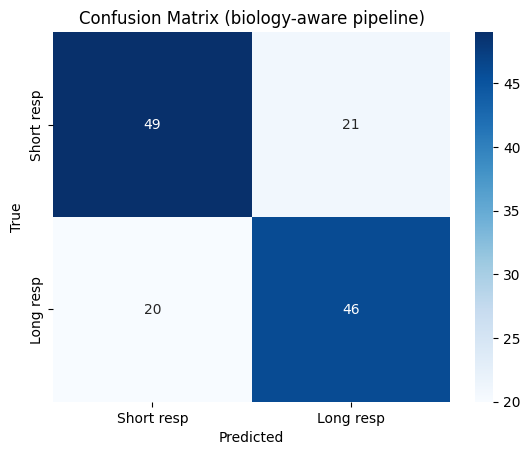

In [22]:
full_pipe.set_params(**study.best_params)

results = cross_validate(
    full_pipe, x, y,
    cv=skf,
    scoring=['roc_auc', 'f1'],
    return_train_score=True,
    n_jobs=-1,
)

print(f"Train ROC-AUC : {results['train_roc_auc'].mean():.3f} ± {results['train_roc_auc'].std():.3f}")
print(f"Train  F1     : {results['train_f1'].mean():.3f} ± {results['train_f1'].std():.3f}")
print(f"Test ROC-AUC  : {results['test_roc_auc'].mean():.3f} ± {results['test_roc_auc'].std():.3f}")
print(f"Test F1       : {results['test_f1'].mean():.3f} ± {results['test_f1'].std():.3f}")

y_pred = cross_val_predict(full_pipe, x, y, cv=skf, n_jobs=-1)

target_names = ['Short resp', 'Long resp']
print(classification_report(y, y_pred, target_names=target_names))

cm = confusion_matrix(y, y_pred)
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=target_names, yticklabels=target_names, cmap='Blues')
plt.ylabel('True'); plt.xlabel('Predicted')
plt.title('Confusion Matrix (biology-aware pipeline)')
plt.show()


## 7. Feature selection stability across folds

In [23]:
selected_per_fold = []
for tr, _ in skf.split(x, y):
    full_pipe.fit(x.iloc[tr], y.iloc[tr])
    names = full_pipe['preprocess'].get_feature_names_out()
    coefs = full_pipe['clf'].coef_[0]
    mask  = coefs != 0
    selected_per_fold.append(set(names[mask]))

common = set.intersection(*selected_per_fold)
union  = set.union(*selected_per_fold)
sizes  = [len(s) for s in selected_per_fold]
print(f'Per-fold sizes:   {sizes}')
print(f'In all folds:     {len(common)}')
print(f'Union size:       {len(union)}')
print(f'Stability ratio:  {len(common) / max(1, min(sizes)):.2f}')
print()
print('Stable features (selected in every fold):')
for f in sorted(common):
    print(f'  {f}')


Per-fold sizes:   [21, 21, 22, 20, 20]
In all folds:     8
Union size:       44
Stability ratio:  0.40

Stable features (selected in every fold):
  age__age
  canonical_gex__gene__NGFR
  categorical__LDH_elevated
  categorical__LDH_normal
  drug_braf__V600E
  m_stage__M_stage
  pathway__pw__H_Hedgehog Signaling
  pathway__pw__KEGG_Melanoma


## 8. Explainability (SHAP)

Now the top features should mostly be **named pathways** and **canonical genes** -- much easier to interpret biologically than `gene_4827`.


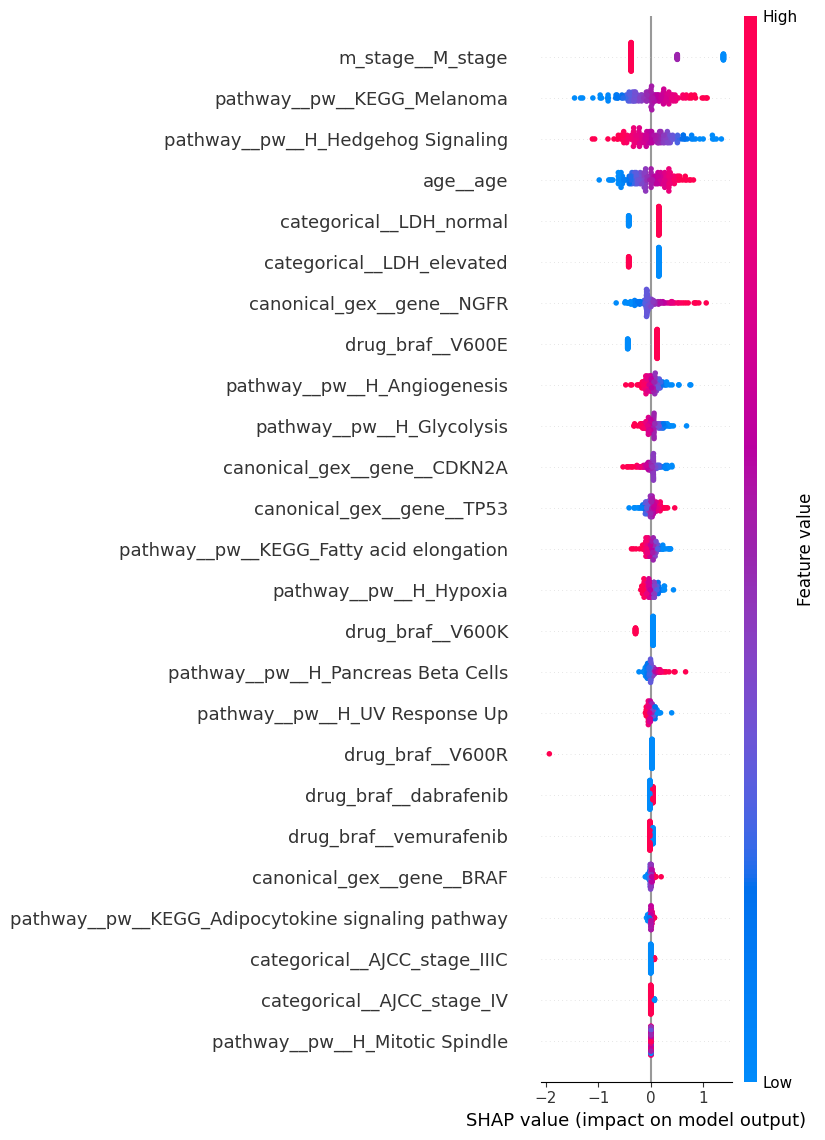

In [24]:
full_pipe.fit(x, y)

x_transformed = full_pipe[:-1].transform(x)
feature_names = full_pipe['preprocess'].get_feature_names_out()

explainer   = shap.LinearExplainer(full_pipe['clf'], x_transformed)
shap_values = explainer(x_transformed)
shap_values.feature_names = feature_names.tolist()

shap.summary_plot(shap_values, x_transformed, feature_names=feature_names, max_display=25)


## 9. Suggestions for next steps

- **Compare side-by-side**: run this notebook and the original `4_simplify_pipe.ipynb` with the same `random_state` and CV splits, then compare F1 / ROC-AUC distributions per fold. A paired test (Wilcoxon over folds) tells you if the biology-aware version is genuinely better.
- **Toggle `KEEP_RAW_GEX = True`**: lets the model use pathways + canonical genes + 500 gene-level features. Sometimes wins; sometimes overfits.
- **Per-treatment models**: if the cohort mixes ICI and MAPKi patients, consider stratifying. Pathway weights for response should differ (immune signatures predict ICI; MAPK output / MITF predict MAPKi resistance).
- **Group lasso**: if you want gene-level resolution with biological structure, replace `LogisticRegression` with a sparse-group-lasso model where groups = pathway membership.
- **Validate signatures separately**: for each custom signature (IPRES, IFN-γ GEP, MITF, AXL), check if it alone separates responders vs non-responders. A simple boxplot stratified by `pfs_label` is often a useful sanity check.
